In [1]:
# Standard library
import sys
from pathlib import Path

# Data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Clustering and dimensionality reduction
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Hierarchical clustering and statistical tests
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import chi2_contingency

# Project-local setup
sys.path.append("../src")
from plot_style import set_project_style, COLOR_DARK, COLOR_ACCENT, COLOR_BG

set_project_style()
data_dir = Path("../data/processed")

In [2]:
patient_features = pd.read_parquet(data_dir / "patient_features.parquet")

print(patient_features.shape)
patient_features.head()

(1763, 20)


,BMI,Creatinine,Glucose,HDL,HbA1c,LDL,Total Cholesterol,Triglycerides,creatinine_measured,BIRTHDATE,DEATHDATE,RACE,ETHNICITY,GENDER,AGE,CCI,on_metformin,on_insulin,on_other_antidiabetic,encounters_per_year
PATIENT,,,,,,,,,,,,,,,,,,,,
0003c6da-971f-a2b1-8693-4c1a27f98985,27.6,2.0,110.2,48.8,3.9,124.3,205.6,162.7,1,1952-03-20,NaT,white,nonhispanic,F,74,4,0,1,0,4.625391
0005fc0b-a254-8215-d848-1a20685b750f,27.9,2.0,97.1,60.7,5.5,104.8,187.8,111.8,1,1945-09-28,NaT,white,nonhispanic,F,80,4,1,0,0,3.821844
0012304f-0715-b5e9-efa2-ee32e57cfb57,30.7,0.9,99.6,53.2,6.2,125.5,200.3,108.1,0,1975-09-07,NaT,white,nonhispanic,F,50,1,1,0,0,1.859094
00681a7d-5dad-ecfe-af77-b65f8da3fa15,28.3,0.9,70.0,52.0,5.6,112.8,178.0,181.2,0,1949-05-20,NaT,white,nonhispanic,F,77,1,1,0,0,1.493300
007603dc-125f-14a7-4318-81aa596339c8,29.4,0.9,77.5,59.3,7.3,78.7,165.6,138.1,0,1979-06-26,NaT,white,nonhispanic,F,46,1,0,0,0,1.772890


In [3]:
patient_features.dtypes

BMI                             float64
Creatinine                      float64
Glucose                         float64
HDL                             float64
HbA1c                           float64
LDL                             float64
Total Cholesterol               float64
Triglycerides                   float64
creatinine_measured               int64
BIRTHDATE                datetime64[us]
DEATHDATE                datetime64[us]
RACE                                str
ETHNICITY                           str
GENDER                              str
AGE                               int64
CCI                               int64
on_metformin                      int64
on_insulin                        int64
on_other_antidiabetic             int64
encounters_per_year             float64
dtype: object

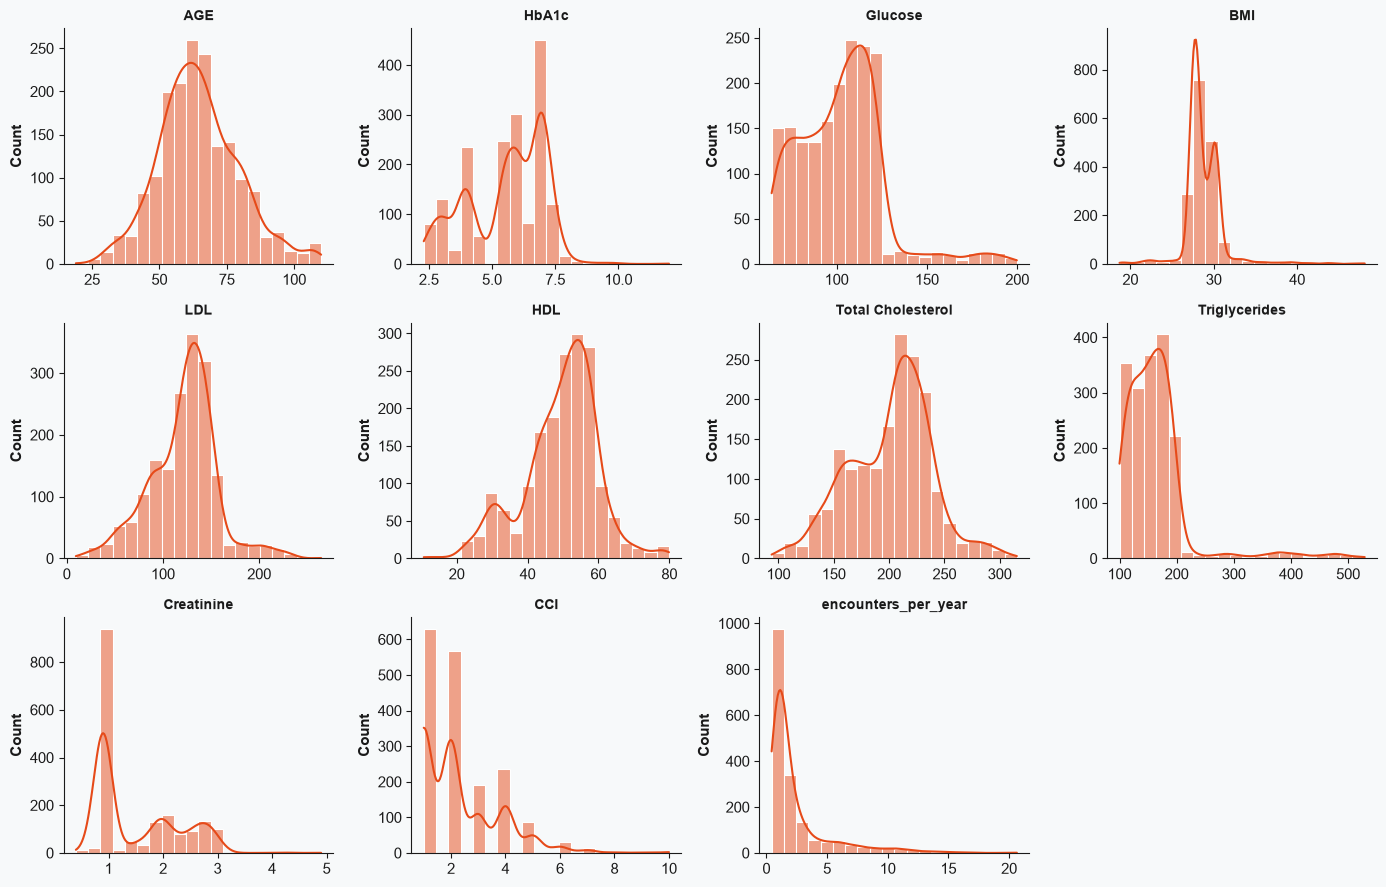

In [4]:
# [Step 1]: Exploratory Data Analysis on patient_features
# Goal: inspect distributions of all numeric features and their pairwise
# correlations, before deciding on any transformation or scaling strategy.

numeric_cols = [
    "AGE", "HbA1c", "Glucose", "BMI", "LDL", "HDL",
    "Total Cholesterol", "Triglycerides", "Creatinine",
    "CCI", "encounters_per_year",
]

# Distribution grid: one histogram per numeric feature
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(patient_features[col], bins = 20, kde=True, ax=ax, color="#E64A19")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

# Hide unused subplot slots (12 grid cells, 11 features)
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**EDA — Distribution observations**

- **HbA1c** is clearly multimodal (peaks around 2.5–3, 4, 6, and 7), suggesting that
  distinct glycemic-control subgroups may already be visible at the univariate level,
  before any multivariate clustering.
- **Glucose** shows a similar pattern: a dominant mass between 75–130 mg/dL plus a
  smaller secondary bump around 175–200 mg/dL, likely the same poorly-controlled
  subgroup visible in HbA1c.
- **BMI** is bimodal (peaks near 28 and 30–31). This may reflect a genuine clinical
  pattern or an artifact of Synthea's population-generation rules. Flagged as a caveat
  to revisit if BMI turns out to be a strong driver of any cluster.
- **Triglycerides** is heavily right-skewed (long tail to ~500 mg/dL). Decision: left
  untransformed (see correlation notes / scaling decision below) rather than
  log-transformed.
- **Creatinine** shows a large artificial spike just above 0.9–1.0 mg/dL — the visual
  signature of the Phase 2 imputation strategy (reference-value imputation for the
  52.4% missing), not a clinical pattern. The smaller, multimodal mass between
  1.5–3 mg/dL represents the actually measured values. The `creatinine_measured` flag
  must be used during cluster profiling to avoid misreading this artifact as signal.
- **CCI** and **encounters_per_year** both confirm the right-skewed, count-like shapes
  already anticipated in `docs/protocol.md`.

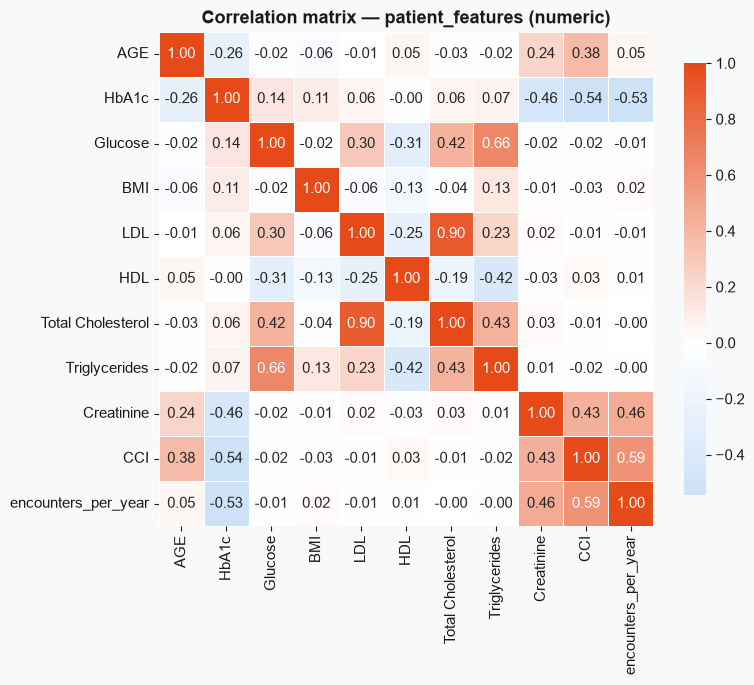

In [5]:
# Correlation matrix among numeric features.
# project_diverging colormap, centered at 0: white = no correlation,
# consistent with the "neutral signal" convention established in Phase 2.
corr = patient_features[numeric_cols].corr()

plt.figure(figsize=(8, 7))
sns.heatmap(
    corr,
    cmap="project_diverging",
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation matrix — patient_features (numeric)")
plt.tight_layout()
plt.show()

**EDA — Correlation observations**

- **LDL vs Total Cholesterol**: r = 0.90 → strong multicollinearity, expected
  clinically (Total Cholesterol is largely determined by LDL). <br>**Decision**: Total
  Cholesterol dropped from the feature set; LDL retained as the more standard lipid
  marker in T2D literature.
- **HbA1c vs CCI / encounters_per_year / Creatinine**: all three negatively correlated
  with HbA1c (-0.54, -0.53, -0.46 respectively). Counter-intuitive at first glance,
  but clinically plausible: patients with more comorbidities and more healthcare
  contact tend to have their antidiabetic therapy more closely titrated, resulting in
  *better* glycemic control despite higher disease burden. This is an early,
  data-driven signal that **H3 ("multi-morbid")** and **H4 ("poor glycemic control")**,
  defined in `docs/protocol.md` Section 5, may represent genuinely distinct phenotypes
  rather than an overlapping one, to be confirmed by clustering.
- **Creatinine, CCI, encounters_per_year** correlate consistently with each other
  (0.43–0.59), forming an internally coherent "disease burden" axis, a good sign of
  data quality in the synthetic cohort.
- **Glucose vs Triglycerides**: r = 0.66, plausible co-occurrence within metabolic
  syndrome.

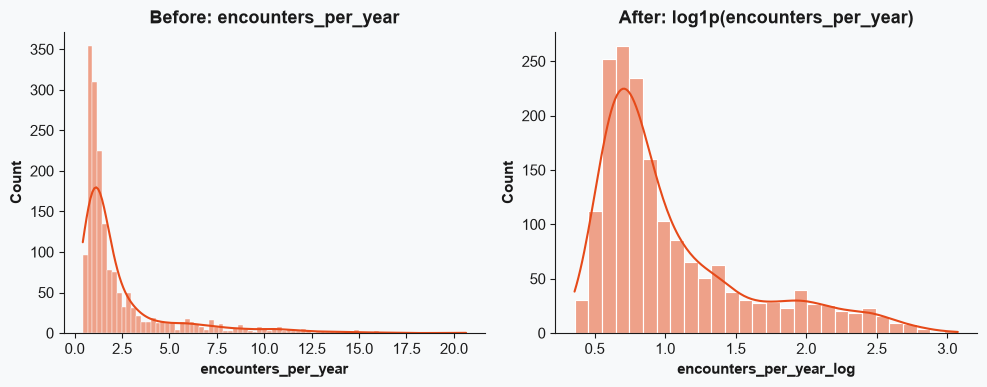

In [6]:
# [Step 2]: Address multicollinearity and skewness, ahead of scaling
# Decisions (logged in docs/protocol.md, Section 4/7):
#   - Total Cholesterol dropped: correlated 0.90 with LDL; LDL retained as the
#     more standard lipid marker in T2D literature.
#   - encounters_per_year log-transformed: right-skewed (median 1.31, max 20.64).
#     log1p used instead of log to safely handle any value at or near 0.

patient_features = patient_features.drop(columns=["Total Cholesterol"])
patient_features["encounters_per_year_log"] = np.log1p(patient_features["encounters_per_year"])

# Quick visual check that the transform did its job
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(patient_features["encounters_per_year"], kde=True, ax=axes[0], color="#E64A19")
axes[0].set_title("Before: encounters_per_year")
sns.histplot(patient_features["encounters_per_year_log"], kde=True, ax=axes[1], color="#E64A19")
axes[1].set_title("After: log1p(encounters_per_year)")
plt.tight_layout()
plt.show()

In [7]:
# [Step 3]: Encode categorical variables for clustering input
# GENDER: binary, mapped directly.
# RACE / ETHNICITY: one-hot encoded, ALL categories kept (drop_first=False).
#
# Note on drop_first=False: for distance-based clustering (unlike regression),
# we deliberately keep every category instead of dropping a reference one.
# Example with 3 categories A, B, C: if B is dropped as reference, a patient
# with B becomes the all-zero vector. Distance(A, B) = 1, but distance(A, C) =
# sqrt(2) -- the categories are no longer equidistant from each other, which
# breaks the symmetry one-hot encoding is meant to provide. Keeping all
# categories makes every pair of distinct categories equidistant (sqrt(2)),
# which is the correct geometric assumption for KMeans.

patient_features["GENDER"] = patient_features["GENDER"].map({"M": 0, "F": 1})

categorical_cols = ["RACE", "ETHNICITY"]
patient_features = pd.get_dummies(
    patient_features, columns=categorical_cols, drop_first=False, dtype=int
)

print(patient_features.shape)
patient_features.columns.tolist()

(1763, 26)


['BMI',
 'Creatinine',
 'Glucose',
 'HDL',
 'HbA1c',
 'LDL',
 'Triglycerides',
 'creatinine_measured',
 'BIRTHDATE',
 'DEATHDATE',
 'GENDER',
 'AGE',
 'CCI',
 'on_metformin',
 'on_insulin',
 'on_other_antidiabetic',
 'encounters_per_year',
 'encounters_per_year_log',
 'RACE_asian',
 'RACE_black',
 'RACE_hawaiian',
 'RACE_native',
 'RACE_other',
 'RACE_white',
 'ETHNICITY_hispanic',
 'ETHNICITY_nonhispanic']

In [8]:
# [Step 4]: Feature scaling
# RobustScaler (median/IQR) applied to continuous variables only, to limit the
# influence of residual outliers (Triglycerides, Creatinine) on the clustering
# distance metric. Binary and one-hot encoded variables are left untouched —
# they already live on a 0-1 scale, and z-scoring them would not add information
# useful to KMeans.
#
# Note: encounters_per_year_log is used here (not the raw encounters_per_year),
# and BIRTHDATE/DEATHDATE are excluded entirely — they're identifiers/dates, not
# clustering features. Both stay in patient_features for later profiling.

continuous_cols = [
    "AGE", "HbA1c", "Glucose", "BMI", "LDL", "HDL",
    "Triglycerides", "Creatinine", "CCI", "encounters_per_year_log",
]

binary_cols = [
    "GENDER", "creatinine_measured",
    "on_metformin", "on_insulin", "on_other_antidiabetic",
] + [c for c in patient_features.columns if c.startswith("RACE_") or c.startswith("ETHNICITY_")]

# Final feature matrix for clustering (separate from patient_features,
# which remains the full, unscaled reference table for profiling)
X_scaled = patient_features[continuous_cols + binary_cols].copy()

scaler = RobustScaler()
X_scaled[continuous_cols] = scaler.fit_transform(X_scaled[continuous_cols])

print(X_scaled.shape)
X_scaled.head()

(1763, 23)


,AGE,HbA1c,Glucose,BMI,LDL,HDL,Triglycerides,Creatinine,CCI,encounters_per_year_log,...,on_insulin,on_other_antidiabetic,RACE_asian,RACE_black,RACE_hawaiian,RACE_native,RACE_other,RACE_white,ETHNICITY_hispanic,ETHNICITY_nonhispanic
PATIENT,,,,,,,,,,,,,,,,,,,,,
0003c6da-971f-a2b1-8693-4c1a27f98985,0.578947,-0.724138,0.222581,-0.217391,-0.032459,-0.195122,0.127985,0.916667,1.0,1.513718,...,1,0,0,0,0,0,0,1,0,1
0005fc0b-a254-8215-d848-1a20685b750f,0.894737,-0.172414,-0.200000,-0.086957,-0.519351,0.772358,-0.844317,0.916667,1.0,1.251568,...,0,0,0,0,0,0,0,1,0,1
0012304f-0715-b5e9-efa2-ee32e57cfb57,-0.684211,0.068966,-0.119355,1.130435,-0.002497,0.162602,-0.914995,0.000000,-0.5,0.362648,...,0,0,0,0,0,0,0,1,0,1
00681a7d-5dad-ecfe-af77-b65f8da3fa15,0.736842,-0.137931,-1.074194,0.086957,-0.319600,0.065041,0.481375,0.000000,-0.5,0.129813,...,0,0,0,0,0,0,0,1,0,1
007603dc-125f-14a7-4318-81aa596339c8,-0.894737,0.448276,-0.832258,0.565217,-1.171036,0.658537,-0.341929,0.000000,-0.5,0.310578,...,0,0,0,0,0,0,0,1,0,1


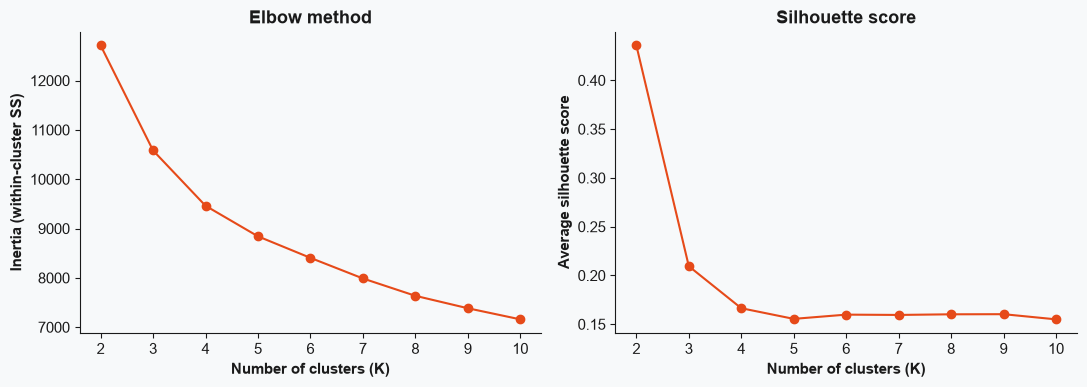

In [9]:
# [Step 5]: Determine K — elbow method + silhouette score
# No fixed K a priori (protocol Section 7, step 4). Both metrics are computed
# across a range of candidate K values; the final choice is made by reading
# them together, not by picking either mechanically.

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(k_range), inertias, marker="o", color="#E64A19")
axes[0].set_title("Elbow method")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia (within-cluster SS)")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="#E64A19")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Average silhouette score")

plt.tight_layout()
plt.show()

**K selection: elbow vs silhouette (open question)**

- **Elbow method**: inertia drops sharply up to K=4 (12,700 → 9,450), then declines
  more gradually and near-linearly from K=4 onward, without a second clear elbow.
  Read in isolation, this would point to K=4 or K=5.
- **Silhouette score**: tells a different story. K=2 dominates (~0.44), well above
  every other K, which then flattens at ~0.16–0.21 from K=3 through K=10, no local
  maximum at K=4.
- **Reference scale** (Kaufman & Rousseeuw): silhouette >0.5 = strong structure,
  0.25–0.5 = reasonable structure, <0.25 = weak/artificial structure. By this scale,
  **only K=2 reaches "reasonable" structure**; K≥3, including K=4 (which would map
  onto the 4 clinical hypotheses in `docs/protocol.md` Section 5), falls in the
  "weak" range.
- **Interpretation**: this is a common pattern in EHR-based patient subtyping,
  clinical phenotypes are often a continuum with fuzzy boundaries rather than
  cleanly separated blobs in feature space (a limitation acknowledged in Ahlqvist
  et al. as well). Not necessarily a flaw in the pipeline.
- **Open question**: does the dominant K=2 split represent a coarse but real
  clinical distinction (e.g., low vs. high overall disease burden), or is it being
  driven by a single high-variance feature dominating the Euclidean distance?
- **Next**: two diagnostics before committing to a final K:
  1. Profile the K=2 split on original (unscaled) feature values, for clinical
     interpretability.
  2. Inspect a ward-linkage dendrogram, to check whether K=4 emerges as a natural
     nested refinement of the K=2 split (each K=2 branch cleanly splitting into two
     sub-branches at a finer distance threshold), evidence the elbow/silhouette
     curves alone can't provide.

In [10]:
# [Diagnostic 1]: what does the K=2 split actually represent, clinically?
# Profile using ORIGINAL (unscaled) values for interpretability —
# always profile in real-world units, never in scaled/z-score units.

km2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_k2 = km2.fit_predict(X_scaled)

profile_cols = ["AGE", "HbA1c", "BMI", "CCI", "Creatinine",
                "encounters_per_year", "on_insulin", "on_metformin"]

print(pd.Series(labels_k2).value_counts())
patient_features.assign(cluster_k2=labels_k2).groupby("cluster_k2")[profile_cols].mean()

0    1664
1      99
Name: count, dtype: int64


,AGE,HbA1c,BMI,CCI,Creatinine,encounters_per_year,on_insulin,on_metformin
cluster_k2,,,,,,,,
0,64.728966,5.586779,28.637680,2.323918,1.517969,2.418468,0.377404,0.476562
1,62.777778,5.449495,30.919192,2.111111,1.448485,2.483741,0.303030,0.979798


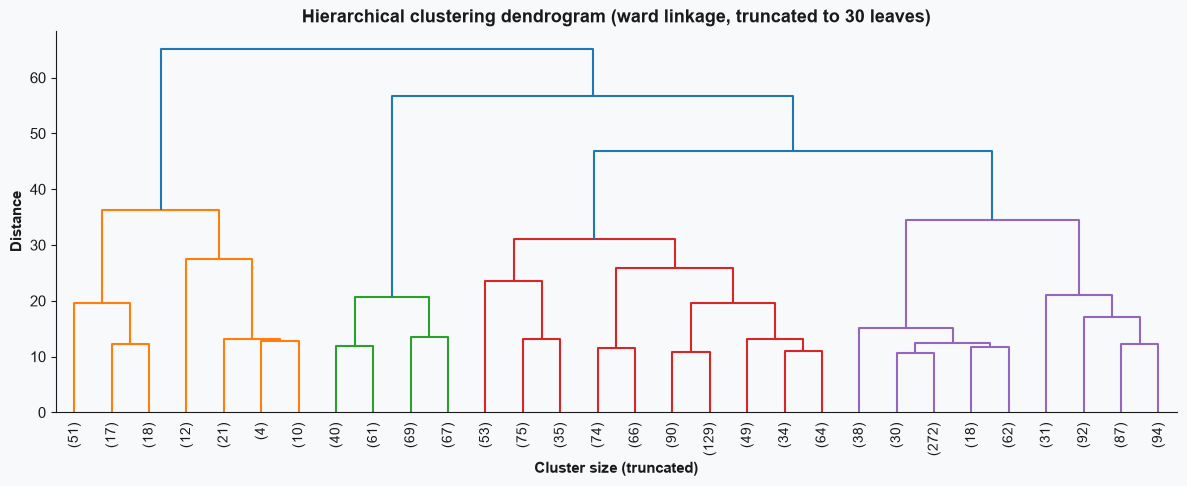

In [11]:
# [Diagnostic 2]: dendrogram from agglomerative clustering (ward linkage).
# This also kickstarts the second algorithm required by the protocol
# (Section 7, step 5). Useful here because a dendrogram can reveal whether
# K=4 is a natural refinement of the K=2 split (i.e., the two K=2 branches
# each split cleanly into two more at a slightly finer distance threshold) —
# something the elbow/silhouette curves alone can't show.

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Hierarchical clustering dendrogram (ward linkage, truncated to 30 leaves)")
plt.xlabel("Cluster size (truncated)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

**Diagnosing the elbow/silhouette conflict, deciding to exclude binary features**

- The initial elbow/silhouette run (full feature set: scaled continuous variables +
  unscaled binary/one-hot medication and demographic dummies) produced conflicting
  signals. Elbow pointed toward K=4–5; silhouette sharply favored K=2 (~0.44), with
  every K≥3 falling into "weak structure" territory (<0.25, Kaufman-Rousseeuw scale).
- **Diagnostic 1 — profiling the K=2 split** on original (unscaled) values: `AGE`,
  `HbA1c`, `CCI`, `Creatinine`, and `encounters_per_year` were nearly identical between
  the two clusters, while `on_metformin` differed sharply (47.7% vs 98.0%). Cluster
  sizes were highly imbalanced (1664 vs 99 patients, ~94%/6%). This indicated the K=2
  split was driven primarily by medication assignment, not by the clinical severity
  axis the protocol's H1-H4 hypotheses are built around.
- **Diagnostic 2 — ward-linkage dendrogram** (full feature set): showed 4 visually
  colored branches, but this is scipy's default 0.7×max-height color threshold, not a
  statistically chosen K. The relative merge-height gap between the two largest
  branches (red/purple, ~669 and ~724 patients) was much smaller than for the other
  two (orange/green), suggesting a natural cut closer to K=3 than K=4.
- **Root cause hypothesis**: with 13 binary/one-hot columns (medication flags,
  `GENDER`, `RACE`, `ETHNICITY`) left unscaled alongside 10 `RobustScaler`-scaled
  continuous columns, the binary block, each dimension contributing a fixed 0/1
  squared distance regardless of clinical relevance, was likely dominating overall
  Euclidean distance and overshadowing the continuous clinical signal.
- **Decision**: re-run elbow/silhouette (and the dendrogram) using only the 10
  continuous clinical features (`AGE`, `HbA1c`, `Glucose`, `BMI`, `LDL`, `HDL`,
  `Triglycerides`, `Creatinine`, `CCI`, `encounters_per_year_log`) as clustering
  inputs. Medication and demographic variables remain in `patient_features` for
  cluster *profiling* and post-hoc equity checks, but are excluded from the distance
  metric driving cluster assignment.
- **Result**: silhouette improved across the board (K=2: 0.44→0.475; K=3: 0.21→0.265;
  K=4: 0.16→0.19). K=3 now crosses the 0.25 "reasonable structure" threshold for the
  first time, consistent with the dendrogram's earlier gap pattern. K=4, the value
  anchored to the protocol's H1-H4 hypotheses, remains below threshold.
- **Open question carried forward**: proceed with K=3 (best statistical support) or
  K=4 (best clinical-hypothesis alignment, weaker statistical support)? To be resolved
  using the clinical-features-only dendrogram (pending) plus qualitative cluster
  profiling against H1-H4.

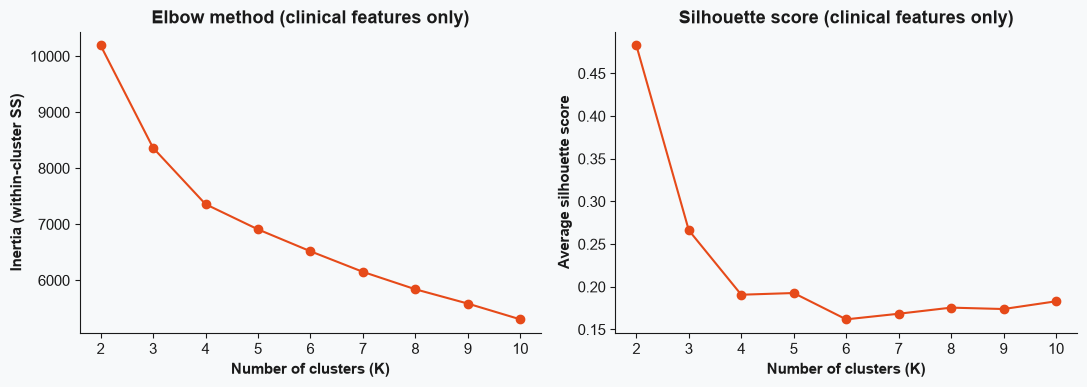

In [12]:
# Re-run K selection using ONLY continuous clinical variables + CCI,
# excluding medication and demographic categorical features (GENDER,
# RACE, ETHNICITY, creatinine_measured, on_metformin, on_insulin,
# on_other_antidiabetic). These remain available in patient_features /
# X_scaled for cluster profiling later -- just not as clustering inputs.

X_clinical = X_scaled[continuous_cols].copy()

k_range = range(2, 11)
inertias_clinical = []
silhouette_scores_clinical = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clinical)
    inertias_clinical.append(km.inertia_)
    silhouette_scores_clinical.append(silhouette_score(X_clinical, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(list(k_range), inertias_clinical, marker="o", color="#E64A19")
axes[0].set_title("Elbow method (clinical features only)")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("Inertia (within-cluster SS)")

axes[1].plot(list(k_range), silhouette_scores_clinical, marker="o", color="#E64A19")
axes[1].set_title("Silhouette score (clinical features only)")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Average silhouette score")

plt.tight_layout()
plt.show()

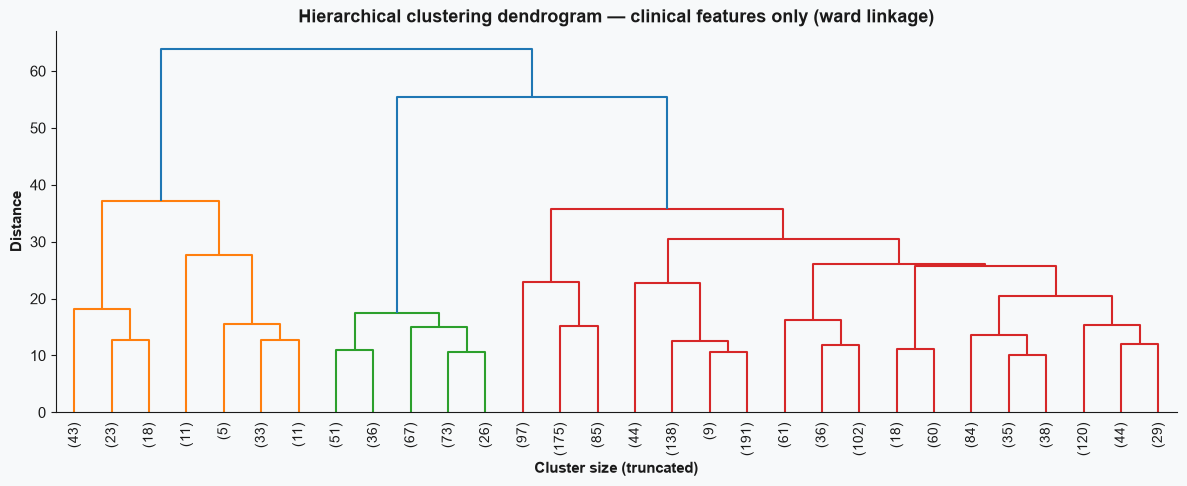

In [13]:
# Dendrogram on the clinical-features-only subset, for direct comparison
# with the silhouette/elbow results above and the earlier full-feature
# dendrogram (which suggested K=3 as the more natural cut).

Z_clinical = linkage(X_clinical, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z_clinical, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Hierarchical clustering dendrogram — clinical features only (ward linkage)")
plt.xlabel("Cluster size (truncated)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [14]:
# [Step 6]: Final clustering models — K=3 (primary) and K=4 (carried for comparison)
# Two algorithms per K (KMeans + Agglomerative, ward linkage — same linkage already
# used for the dendrogram), to check whether two independent methods agree on the
# same partition. Run on X_clinical (clinical-features-only, per the Step 5 decision).

for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")

    km_labels = km.fit_predict(X_clinical)
    agg_labels = agg.fit_predict(X_clinical)

    ari = adjusted_rand_score(km_labels, agg_labels)
    print(f"K={k}: Adjusted Rand Index (KMeans vs Agglomerative) = {ari:.3f}")

    patient_features[f"kmeans_k{k}"] = km_labels
    patient_features[f"agglomerative_k{k}"] = agg_labels

K=3: Adjusted Rand Index (KMeans vs Agglomerative) = 0.703
K=4: Adjusted Rand Index (KMeans vs Agglomerative) = 0.327


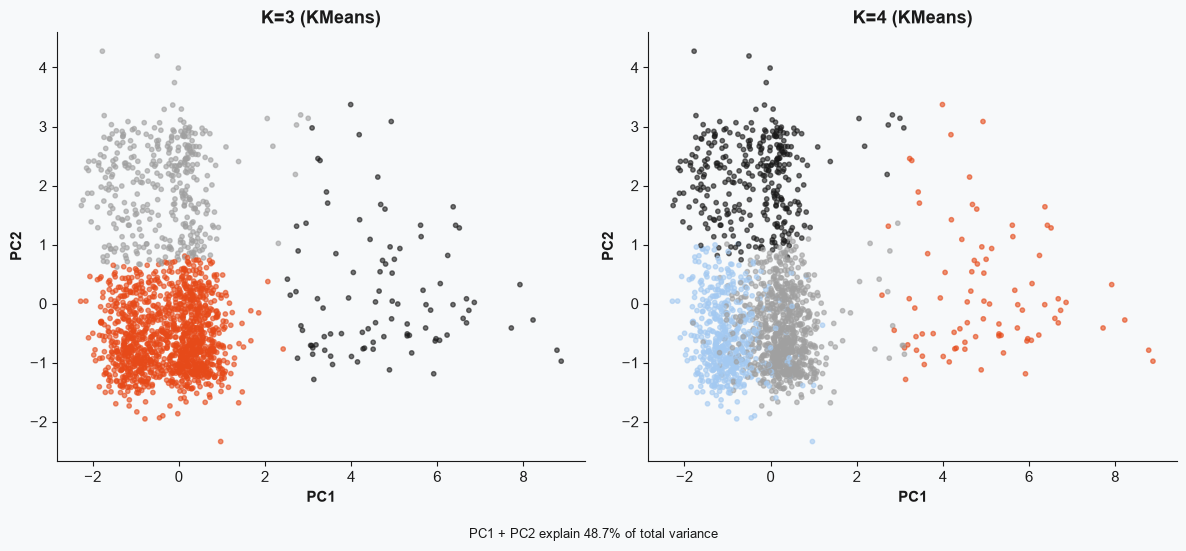

In [15]:
# [Step 7a]: PCA visualization (Section 7, point 6) -- visual check on whether the
# K=4 split creates a genuinely separate blob, or just slices through an existing
# dense region (which would visually corroborate the low ARI for K=4).

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clinical)

# Discrete palette from the project's established colors. Note: cluster labels
# are categorical, not ordinal -- using project_mono (a continuous gradient)
# here would be misleading, since it implies an ordering between clusters
# that doesn't exist. A small set of visually distinct hues is more correct.
cluster_palette = ListedColormap(["#E64A19", "#A3C9F1", "#1A1A1A", "#A0A0A0"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, k in zip(axes, [3, 4]):
    labels = patient_features[f"kmeans_k{k}"]
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap=cluster_palette, s=10, alpha=0.6)
    ax.set_title(f"K={k} (KMeans)")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

variance_explained = pca.explained_variance_ratio_[:2].sum() * 100
fig.text(
    0.5, 0.01,
    f"PC1 + PC2 explain {variance_explained:.1f}% of total variance",
    ha="center", fontsize=9, color="#1A1A1A",
)

# rect reserves bottom margin so the caption doesn't overlap the x-axis labels
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

**Caveat on the 48.7% variance explained by PC1+PC2**

- Less than half of the total variance in the 10-dimensional clinical feature space
  is captured by the two-dimensional PCA projection used for visualization. This
  means the 2D scatter is a simplification, not a complete picture, over half of
  the structure in the original space is invisible in this plot.
- **Implication**: visual cluster separation in this PCA plot should be treated as
  *corroborating* evidence, not primary evidence. A cluster boundary that looks weak
  in 2D could still be sharp in the full feature space, and vice versa.
- In this case, however, the PCA reading agrees with three independent diagnostics
  already gathered (silhouette score, dendrogram branch gaps, ARI between KMeans and
  Agglomerative): the small, distant subgroup is visually identical and stable across
  both K=3 and K=4, while the large dense mass is split into two halves with no
  visible gap or density change between them when moving from K=3 to K=4, consistent
  with the low ARI (0.327) observed for K=4, which indicated the two algorithms
  disagree on exactly how to make that cut.
- Side note on feature engineering: a moderate (not extreme) concentration of
  variance in the first two components is itself a mildly reassuring sign, it
  suggests no single pair of highly correlated variables is artificially inflating
  PC1 (the kind of effect the Total Cholesterol/LDL multicollinearity, addressed in
  Step 2, could have caused if left unresolved).

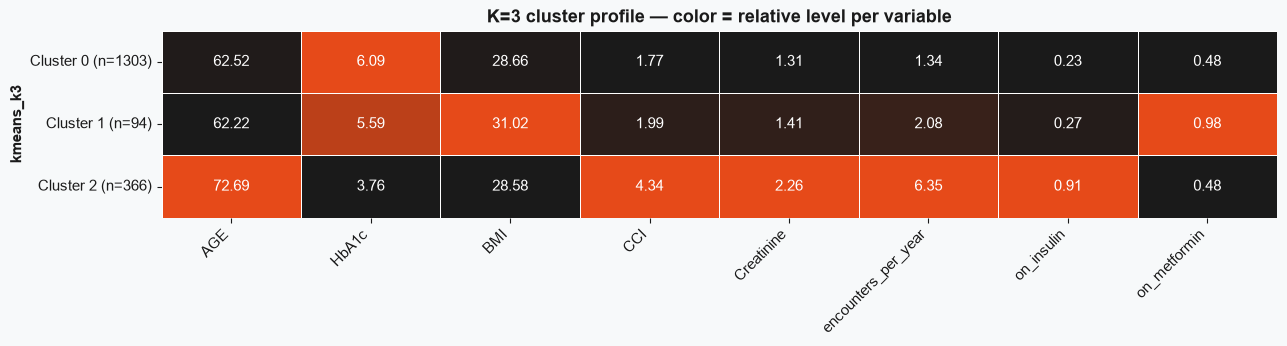

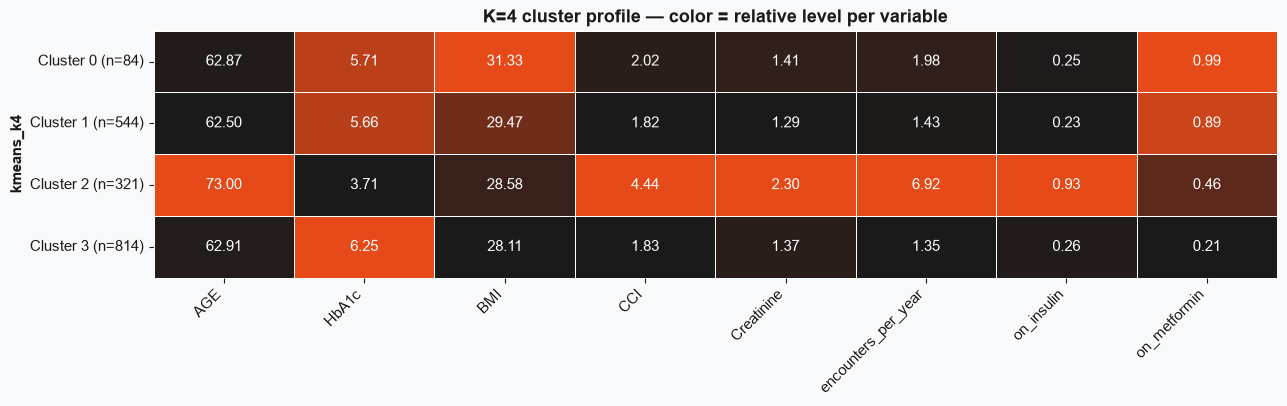

In [16]:
# [Step 7b]: cluster profiles as annotated heatmaps, replacing the
# separate table. Color is column-wise normalized (min-max across clusters)
# so each variable's relative scale is comparable; annotated text shows the
# real, unscaled value.

for k in [3, 4]:
    profile = patient_features.groupby(f"kmeans_k{k}")[profile_cols].mean()
    sizes = patient_features[f"kmeans_k{k}"].value_counts().sort_index()

    color_scale = (profile - profile.min()) / (profile.max() - profile.min())

    plt.figure(figsize=(13, 1.8 + 0.6 * len(profile)))
    sns.heatmap(
        color_scale, annot=profile, fmt=".2f", cmap="project_mono",
        linewidths=0.5, cbar=False,
        yticklabels=[f"Cluster {i} (n={n})" for i, n in sizes.items()],
    )
    plt.title(f"K={k} cluster profile — color = relative level per variable")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Final cluster profiling conclusions (K=3 confirmed)**

- **K=3 confirmed as the final choice**, supported convergently by silhouette score,
  elbow location, dendrogram branch gaps, and Adjusted Rand Index (0.703, KMeans vs
  Agglomerative), see decision log above.
- **Cluster 0 (n=1303, 73.9%)**: HbA1c 6.09 (near target), CCI 1.77 (lowest),
  encounters_per_year 1.34 (lowest), metformin 48%. Best match to **H2**
  ("mild/late-onset", expected to be the largest subtype), though age (62.5) does
  not show the "older" pattern the hypothesis anticipated.
- **Cluster 1 (n=94, 5.3%)**: BMI 31.0 (highest), Triglycerides 375.9 (more than
  double the other clusters), HDL 29.9 (lowest), metformin near-universal (98%).
  Partial match to **H1** (insulin-resistant/dyslipidemic profile), though again
  without the "younger" criterion the hypothesis specified (age 62.2, same as
  Cluster 0).
- **Cluster 2 (n=366, 20.8%)**: oldest (72.7), CCI 4.34, encounters_per_year 6.35,
  Creatinine 2.26 (99% measured), insulin 91%. Strong, near-complete match to **H3**
  (multi-morbid).
- **H4 ("poor glycemic control despite intensive therapy") not confirmed by any
  cluster.** The data show the opposite pattern: Cluster 2, the most intensively
  treated (91% on insulin), has the *lowest* HbA1c (3.76); Cluster 0, the least
  intensively treated (23% on insulin), has the *highest* HbA1c (6.09) of the three.
  This is consistent with the inverse HbA1c-CCI/encounters correlation already
  observed at the univariate level in Step 1. **Reinterpretation, to be logged as a
  protocol deviation**: rather than treatment-resistant poor control, the pattern
  more plausibly reflects *undertreatment*, patients with worse glycemic control
  receive less intensive pharmacological management, not more.
- **K=4 evaluated and not adopted**: it reproduces Clusters 1 and 2 essentially
  unchanged, and splits Cluster 0 into two halves that differ mainly in metformin
  use (89% vs 21%) and LDL, with no difference in age, CCI, or encounters, a
  treatment/lipid-control gradient inside the same population, not a new severity
  axis. Consistent with the low ARI (0.327) and the absence of a visible gap in both
  the dendrogram and the PCA projection for K=4. Flagged as a possible direction for
  future work (e.g., a continuous treatment-adherence score within Cluster 0) rather
  than a basis for a fourth cluster.

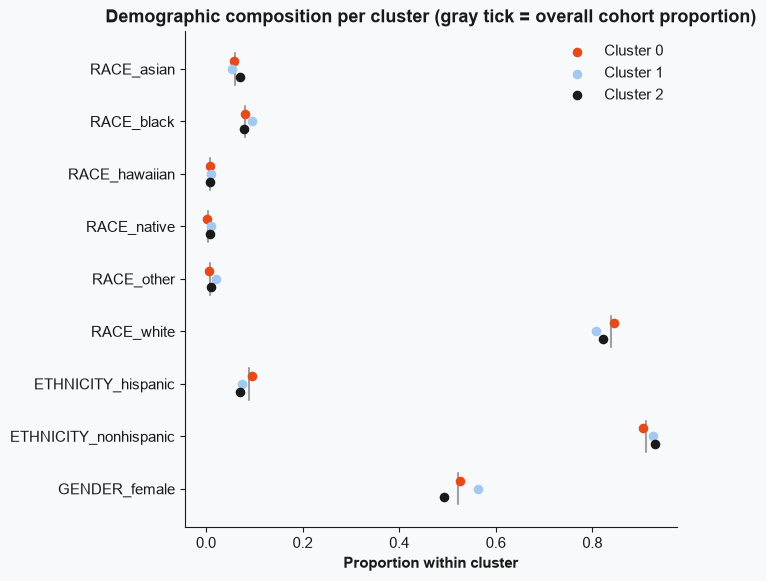

In [18]:
# [Step 8]: Post-hoc equity check - distribution of GENDER, RACE, ETHNICITY
# across clusters. These were deliberately excluded as clustering inputs
# (Step 5 decision); this checks whether the resulting clinical phenotypes
# are nonetheless disproportionately distributed across demographic groups.

race_cols = [c for c in patient_features.columns if c.startswith("RACE_")]
ethnicity_cols = [c for c in patient_features.columns if c.startswith("ETHNICITY_")]
demo_cols = race_cols + ethnicity_cols + ["GENDER"]
cluster_ids = sorted(patient_features["kmeans_k3"].unique())
cluster_colors = ["#E64A19", "#A3C9F1", "#1A1A1A"]

rows = []
for col in demo_cols:
    label = "GENDER_female" if col == "GENDER" else col
    overall = patient_features[col].mean()
    for k in cluster_ids:
        prop = patient_features.loc[patient_features["kmeans_k3"] == k, col].mean()
        rows.append({"category": label, "cluster": k, "proportion": prop, "overall": overall})

demo_long = pd.DataFrame(rows)
categories = list(demo_long["category"].unique())  # preserves RACE -> ETHNICITY -> GENDER order
y_pos = {cat: i for i, cat in enumerate(categories)}

fig, ax = plt.subplots(figsize=(7, 0.55 * len(categories) + 1))

for cat in categories:
    y = y_pos[cat]
    overall = demo_long.loc[demo_long["category"] == cat, "overall"].iloc[0]
    ax.plot([overall, overall], [y - 0.3, y + 0.3], color="#A0A0A0", lw=1.5, zorder=1)

for k, color in zip(cluster_ids, cluster_colors):
    sub = demo_long[demo_long["cluster"] == k]
    offsets = [y_pos[c] + (k - 1) * 0.15 for c in sub["category"]]
    ax.scatter(sub["proportion"], offsets, color=color, s=35, label=f"Cluster {k}", zorder=2)

ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories)
ax.set_xlabel("Proportion within cluster")
ax.set_title("Demographic composition per cluster (gray tick = overall cohort proportion)")
ax.legend(frameon=False, loc="upper right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
p_values = []
for label, cols in [("RACE", race_cols), ("ETHNICITY", ethnicity_cols)]:
    counts = patient_features.groupby("kmeans_k3")[cols].sum()
    _, p, _, _ = chi2_contingency(counts)
    p_values.append(f"{label} p={p:.3f}")

gender_counts = pd.crosstab(patient_features["kmeans_k3"], patient_features["GENDER"])
_, p, _, _ = chi2_contingency(gender_counts)
p_values.append(f"GENDER p={p:.3f}")

print("Chi-square test (cluster vs demographic group): " + ", ".join(p_values))

Chi-square test (cluster vs demographic group): RACE p=0.611, ETHNICITY p=0.294, GENDER p=0.350


**Demographic equity check (post-hoc)**

- `RACE`, `ETHNICITY`, and `GENDER` were deliberately excluded from clustering inputs
  (Step 5) specifically to allow this post-hoc check: do the resulting clinical
  phenotypes disproportionately reflect demographic groups?
- **Result: no significant association found.** RACE (chi2=8.18, p=0.611),
  ETHNICITY (chi2=2.45, p=0.294), and GENDER (chi2=2.10, p=0.350) are all distributed
  essentially evenly across the three clusters, proportions per cluster closely
  track the overall cohort composition.
- **Caveat**: `RACE_hawaiian` and `RACE_native` each represent ~1% of the cohort
  (~17-18 patients total across 3 clusters); expected cell counts for these
  categories likely fall below the conventional reliability threshold (≥5) for the
  chi-square test. The overall test result stands, but this specific null finding
  for the rarest categories should be read with appropriate caution rather than
  treated as definitive.
- **Conclusion**: the K=3 phenotypes appear to reflect clinical/metabolic
  differences rather than demographic composition, a reassuring result for the
  validity of the subtyping, though not a substitute for a dedicated fairness audit
  with adequate power for rare subgroups.

In [ ]:
# [Step 9:] Finalize cluster labels, drop rejected/redundant assignments
# - Human-readable label per K=3 cluster, based on the Section 7.6 profiling
# - kmeans_k4/agglomerative_k4 dropped (K=4 rejected as final model)
# - agglomerative_k3 also dropped: it served only the ARI robustness check in
#   Step 6, not needed as a standalone label going forward (kmeans_k3 is the
#   adopted, canonical assignment)

cluster_label_map = {
    0: "Mild, lower treatment intensity",
    1: "Dyslipidemic / metabolic",
    2: "Multimorbid, high care complexity",
}
patient_features["cluster_label"] = patient_features["kmeans_k3"].map(cluster_label_map)

patient_features = patient_features.drop(columns=["kmeans_k4", "agglomerative_k4", "agglomerative_k3"])
patient_features.head()

,BMI,Creatinine,Glucose,HDL,HbA1c,LDL,Triglycerides,creatinine_measured,BIRTHDATE,DEATHDATE,...,RACE_asian,RACE_black,RACE_hawaiian,RACE_native,RACE_other,RACE_white,ETHNICITY_hispanic,ETHNICITY_nonhispanic,kmeans_k3,cluster_label
PATIENT,,,,,,,,,,,,,,,,,,,,,
0003c6da-971f-a2b1-8693-4c1a27f98985,27.6,2.0,110.2,48.8,3.9,124.3,162.7,1,1952-03-20,NaT,...,0,0,0,0,0,1,0,1,2,"Multimorbid, high care complexity"
0005fc0b-a254-8215-d848-1a20685b750f,27.9,2.0,97.1,60.7,5.5,104.8,111.8,1,1945-09-28,NaT,...,0,0,0,0,0,1,0,1,2,"Multimorbid, high care complexity"
0012304f-0715-b5e9-efa2-ee32e57cfb57,30.7,0.9,99.6,53.2,6.2,125.5,108.1,0,1975-09-07,NaT,...,0,0,0,0,0,1,0,1,0,"Mild, lower treatment intensity"
00681a7d-5dad-ecfe-af77-b65f8da3fa15,28.3,0.9,70.0,52.0,5.6,112.8,181.2,0,1949-05-20,NaT,...,0,0,0,0,0,1,0,1,0,"Mild, lower treatment intensity"
007603dc-125f-14a7-4318-81aa596339c8,29.4,0.9,77.5,59.3,7.3,78.7,138.1,0,1979-06-26,NaT,...,0,0,0,0,0,1,0,1,0,"Mild, lower treatment intensity"


In [ ]:
# [Step 10]: Build an export-ready table. Reconstruct readable RACE/ETHNICITY
# from the one-hot block, more directly usable downstream (notebook 03,
# Power BI) than 8 separate dummy columns, and drop the dummies from the
# exported copy. patient_features itself stays untouched.

race_cols = [c for c in patient_features.columns if c.startswith("RACE_")]
ethnicity_cols = [c for c in patient_features.columns if c.startswith("ETHNICITY_")]

export_df = patient_features.copy()
export_df["RACE"] = export_df[race_cols].idxmax(axis=1).str.replace("RACE_", "", regex=False)
export_df["ETHNICITY"] = export_df[ethnicity_cols].idxmax(axis=1).str.replace("ETHNICITY_", "", regex=False)
export_df = export_df.drop(columns=race_cols + ethnicity_cols)
export_df.head()

,BMI,Creatinine,Glucose,HDL,HbA1c,LDL,Triglycerides,creatinine_measured,BIRTHDATE,DEATHDATE,...,CCI,on_metformin,on_insulin,on_other_antidiabetic,encounters_per_year,encounters_per_year_log,kmeans_k3,cluster_label,RACE,ETHNICITY
PATIENT,,,,,,,,,,,,,,,,,,,,,
0003c6da-971f-a2b1-8693-4c1a27f98985,27.6,2.0,110.2,48.8,3.9,124.3,162.7,1,1952-03-20,NaT,...,4,0,1,0,4.625391,1.727291,2,"Multimorbid, high care complexity",white,nonhispanic
0005fc0b-a254-8215-d848-1a20685b750f,27.9,2.0,97.1,60.7,5.5,104.8,111.8,1,1945-09-28,NaT,...,4,1,0,0,3.821844,1.573157,2,"Multimorbid, high care complexity",white,nonhispanic
0012304f-0715-b5e9-efa2-ee32e57cfb57,30.7,0.9,99.6,53.2,6.2,125.5,108.1,0,1975-09-07,NaT,...,1,1,0,0,1.859094,1.050505,0,"Mild, lower treatment intensity",white,nonhispanic
00681a7d-5dad-ecfe-af77-b65f8da3fa15,28.3,0.9,70.0,52.0,5.6,112.8,181.2,0,1949-05-20,NaT,...,1,1,0,0,1.493300,0.913607,0,"Mild, lower treatment intensity",white,nonhispanic
007603dc-125f-14a7-4318-81aa596339c8,29.4,0.9,77.5,59.3,7.3,78.7,138.1,0,1979-06-26,NaT,...,1,0,0,0,1.772890,1.019890,0,"Mild, lower treatment intensity",white,nonhispanic


In [25]:
# [Step 11]: Export -- parquet for notebook 03 (Python reuse), CSV for Power BI
# (PATIENT reset to a plain column for the CSV: Power Query handles an
# explicit column more predictably than an index written as the first,
# unlabeled CSV column).

export_df.to_parquet("../data/processed/patient_features_clustered.parquet")
export_df.reset_index().to_csv("../data/processed/patient_features_dashboard.csv", index=False)